In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd 
import polars as pl
import matplotlib.pyplot as plt

import src.clinvar as cv


# ClinVar UTR Variant Data

The VCF file was manually downloaded from the following link: [ClinVar GRCh38 VCF](https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz).

After downloading, variants located in the untranslated regions (UTRs) – including both 3' UTR and 5' UTR variants – were filtered. The filtered data was then written into a CSV file for further analysis.



In [2]:
vcf_file = cv.download_vcf()["vcf"]

In [16]:
vcf_df = cv.vcf_to_df(vcf_file)

print(vcf_df.shape)
vcf_df.head()

Reading records:   0%|          | 0/3498894 [00:00<?, ? record/s]

(228013, 22)


CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,MC_id,MC_term,CLNREVSTAT_score
str,i64,str,list[str],f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,i8
"""1""",981131,"""C""","[""T""]",null,null,null,3393359,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.981131C>T""","""criteria_provided,_single_subm…","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""PERM1:84808""","""SO:0001623|5_prime_UTR_variant…","""1""",null,"""SO:0001623""","""intron_variant""",1
"""1""",1013541,"""T""","[""C""]",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""","""15842""","""SO:0001623""","""5_prime_UTR_variant""",2
"""1""",1013549,"""GGCCCACAGCCCACA""","[""G""]",null,null,null,3213980,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1013553CACAGCC[…","""no_assertion_criteria_provided""","""Likely_benign""","""Microsatellite""","""SO:0000289""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""",null,"""SO:0001623""","""5_prime_UTR_variant""",0
"""1""",1014482,"""C""","[""A""]",null,null,null,3216732,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1014482C>A""","""no_assertion_criteria_provided""","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001624|3_prime_UTR_variant""","""1""",null,"""SO:0001624""","""3_prime_UTR_variant""",0
"""1""",1055000,"""C""","[""T""]",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""3121561""","""SO:0001624""","""3_prime_UTR_variant""",2


In [39]:
bed = cv.df_to_bed(vcf_df, 
                   save_path='data/UTR/clinvar_utr_snv.bed.gz')

print(bed.shape)
bed.head()

(228009, 22)


chrom,chromStart,chromEnd,name,score,strand,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO
str,i64,i64,str,i8,null,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str
"""1""",981131,981132,"""chr1:981131-981132_CT""",1,null,"""C""","""T""","""SO:0001623""","""intron_variant""",null,null,null,3393359,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.981131C>T""","""criteria_provided,_single_subm…","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""PERM1:84808"""
"""1""",1013541,1013542,"""chr1:1013541-1013542_TC""",2,null,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636"""
"""1""",1013549,1013564,"""chr1:1013549-1013564_GGCCCACAG…",0,null,"""GGCCCACAGCCCACA""","""G""","""SO:0001623""","""5_prime_UTR_variant""",null,null,null,3213980,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1013553CACAGCC[…","""no_assertion_criteria_provided""","""Likely_benign""","""Microsatellite""","""SO:0000289""","""ISG15:9636"""
"""1""",1014482,1014483,"""chr1:1014482-1014483_CA""",0,null,"""C""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,null,3216732,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1014482C>A""","""no_assertion_criteria_provided""","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_CT""",2,null,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""


In [38]:
bed.filter(pl.col('ALT').is_null())

chrom,chromStart,chromEnd,name,score,strand,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO
str,i64,i64,str,i8,null,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str


In [37]:
sites = cv.df_to_sites(vcf_df)

sites.head()

CHROM,POS,POS_END,name,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNREVSTAT_score
str,i64,i64,str,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,i8
"""1""",981131,981132,"""chr1:981131-981132_CT""","""C""","""T""","""SO:0001623""","""intron_variant""",null,null,null,3393359,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.981131C>T""","""criteria_provided,_single_subm…","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""PERM1:84808""",1
"""1""",1013541,1013542,"""chr1:1013541-1013542_TC""","""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""",2
"""1""",1013549,1013564,"""chr1:1013549-1013564_GGCCCACAG…","""GGCCCACAGCCCACA""","""G""","""SO:0001623""","""5_prime_UTR_variant""",null,null,null,3213980,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1013553CACAGCC[…","""no_assertion_criteria_provided""","""Likely_benign""","""Microsatellite""","""SO:0000289""","""ISG15:9636""",0
"""1""",1014482,1014483,"""chr1:1014482-1014483_CA""","""C""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,null,3216732,""".""","""ISG15-related_disorder""","""NC_000001.11:g.1014482C>A""","""no_assertion_criteria_provided""","""Likely_benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""",0
"""1""",1055000,1055001,"""chr1:1055000-1055001_CT""","""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2


In [71]:
CLNREVSTAT_opts = ["practice_guideline","reviewed_by_expert_panel"]
MC_term_opts = ["5_prime_UTR_variant","3_prime_UTR_variant"]
CLNSIG_opts = ["benign","pathogenic","Benign","Pathogenic"]

cv_df = vcf_df.filter(
    (pl.col("CLNREVSTAT_score")>=2) &
    (pl.col("MC_term").str.contains("|".join(MC_term_opts))) &
    (pl.col("CLNVC") == "single_nucleotide_variant") &
    (pl.col("CLNSIG").str.contains("|".join(CLNSIG_opts)))
).drop_nulls(subset=['CLNDN'])

# Convert POS column to integer before saving
cv_df = cv_df.with_columns(pl.col("POS").cast(pl.Int64))


save_path = "./data/UTR/clinvar_utr_snv.bed.gz"
print("Saving filteredUTR sites to",save_path)
cv.df_to_bed(cv_df, save_path=save_path)
# cv_df.write_parquet(save_path)

print("Gene count:",cv_df["GENEINFO"].unique().len())
print(cv_df.shape)
cv_df.head()

Saving filteredUTR sites to ./data/UTR/clinvar_utr_snv.bed.gz
Gene count: 3549
(13771, 22)


CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,MC_id,MC_term,CLNREVSTAT_score
str,i64,str,list[str],f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,i8
"""1""",1013541,"""T""","[""C""]",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""SO:0001623|5_prime_UTR_variant""","""1""","""15842""","""SO:0001623""","""5_prime_UTR_variant""",2
"""1""",1055000,"""C""","[""T""]",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""3121561""","""SO:0001624""","""3_prime_UTR_variant""",2
"""1""",1055037,"""T""","[""C""]",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""2465136""","""SO:0001624""","""3_prime_UTR_variant""",2
"""1""",1055137,"""C""","[""T""]",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""2710872""","""SO:0001624""","""3_prime_UTR_variant""",2
"""1""",1055153,"""G""","[""A""]",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""SO:0001624|3_prime_UTR_variant""","""1""","""4308920""","""SO:0001624""","""3_prime_UTR_variant""",2


### Key Definitions:

- **AF_ESP**: Allele Frequency in the ESP (Exome Sequencing Project) population.
- **AF_EXAC**: Allele Frequency in the EXAC (Exome Aggregation Consortium) population.
- **AF_TGP**: Allele Frequency in the TGP (The 1000 Genomes Project) population.
- **ALLELEID**: Unique identifier for the allele.
- **CLNDISDB**: The disease database(s) that the variant is associated with.
- **CLNDN**: Clinical diagnosis associated with the variant (e.g., disease name).
- **CLNHGVS**: The HGVS (Human Genome Variation Society) nomenclature of the variant, representing the change in nucleotide sequence.
- **CLNREVSTAT**: Review status of the clinical interpretation of the variant (e.g., how the variant's pathogenicity has been reviewed).
- **CLNSIG**: Clinical significance of the variant (e.g., benign, pathogenic, likely pathogenic).
- **CLNVC**: Variant classification (e.g., single nucleotide variant).
- **CLNVCSO**: Sequence ontology for the variant (a standardized description of the type of variation).
- **GENEINFO**: Gene associated with the variant (Gene Symbol and Gene ID).
- **MC**: Mutation classification, often indicating the molecular mechanism or impact of the variant.
- **ORIGIN**: The origin of the variant (e.g., germline or somatic).
- **RS**: dbSNP (database of single nucleotide polymorphisms) reference ID.


## Summary

[Source: ClinVar](https://www.ncbi.nlm.nih.gov/clinvar/docs/review_status/)

| Stars | Review Status | Description |
|-------|--------------|-------------|
| ⭐⭐⭐⭐ | practice guideline | There is a submitted record with a classification from a practice guideline |
| ⭐⭐⭐ | reviewed by expert panel | There is a submitted record with a classification from an expert panel |
| ⭐⭐ | criteria provided, multiple submitters, no conflicts | There are multiple submitted records with a classification. Assertion criteria and evidence for the classification (or a public contact) were provided and the classifications agree. |
| ⭐ | criteria provided, conflicting classifications | There are multiple submitted records with a classification, where assertion criteria and evidence for the classification (or a public contact) were provided. However there are conflicting classifications. The conflicting values for the classification are enumerated. |
| ⭐ | criteria provided, single submitter | There is a single submitted record with a classification, where assertion criteria and evidence for the classification (or a public contact) were provided. |
| - | no assertion criteria provided | There are one or more submitted records with a classification but without assertion criteria and evidence for the classification (or a public contact). |
| - | no classification provided | There are one or more submitted records without a classification. |
| - | no classification for the individual variant | The variant was not classified directly in any submitted record; it was submitted to ClinVar only as part of a haplotype or a genotype. |

In [ ]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(-1)


vcf_df["CLNREVSTAT"].value_counts().sort("count", descending=True)
# vcf_df["CLNREVSTAT"].str.split(",").explode().value_counts().sort("count", descending=True)

# Summary of Clinical Significance

Clinical Significance Counts:
shape: (12, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ len   │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Uncertain_significance          ┆ 11998 │
│ Benign                          ┆ 8029  │
│ Likely_benign                   ┆ 1851  │
│ Benign/Likely_benign            ┆ 1836  │
│ Pathogenic/Likely_pathogenic    ┆ 917   │
│ …                               ┆ …     │
│ Uncertain_significance/Uncerta… ┆ 10    │
│ drug_response                   ┆ 2     │
│ Pathogenic/Likely_pathogenic/P… ┆ 2     │
│ Benign|other                    ┆ 1     │
│ Benign|confers_sensitivity      ┆ 1     │
└─────────────────────────────────┴───────┘


<Figure size 1000x800 with 0 Axes>

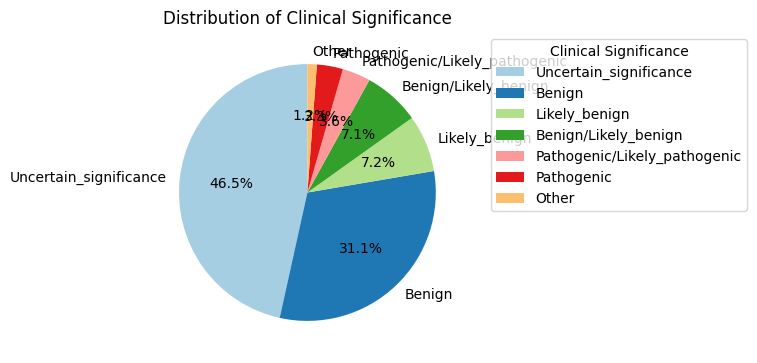

In [60]:
# count the occurrences of each clinical significance value
clnsig_counts = cv_df.group_by("CLNSIG").len().sort("len", descending=True)

print("Clinical Significance Counts:")
print(clnsig_counts)

# select the top N categories and combine the rest into 'Other'
top_n = 6
top_categories = clnsig_counts.head(top_n)
other_categories = clnsig_counts.tail(len(clnsig_counts) - top_n).select(pl.col("len").cast(pl.UInt32).sum()).item()
other_row = pl.DataFrame({"CLNSIG": ["Other"], "len": [other_categories]})
clnsig_counts_filtered = pl.concat([top_categories.with_columns(pl.col("len").cast(pl.Int64)),
                                     other_row])

# Convert to pandas for plotting
clnsig_counts_pd = clnsig_counts_filtered.to_pandas().set_index("CLNSIG")

plt.figure(figsize=(10, 8))
ax = clnsig_counts_pd.plot(kind='pie', y="len", autopct='%1.1f%%', startangle=90, legend=False, colors=plt.cm.Paired.colors)
plt.title('Distribution of Clinical Significance')
plt.ylabel('')
plt.legend(clnsig_counts_pd.index, title="Clinical Significance", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Data summary

# Effect of Variants

<Figure size 1200x800 with 0 Axes>

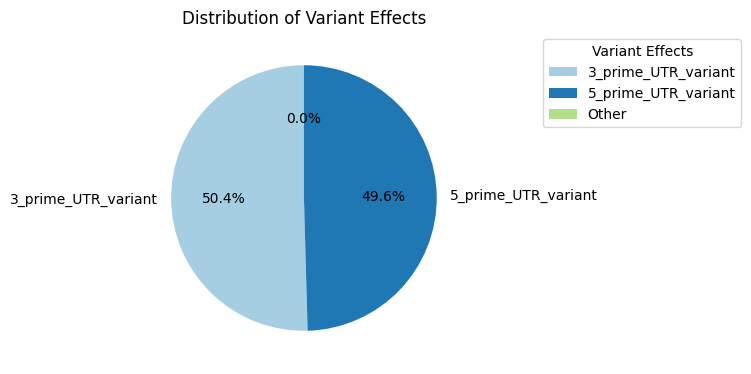

In [61]:
# count the occurrences of each variant effect
effect_counts = cv_df.group_by("MC_term").len().sort("len", descending=True)

# select the top N categories and combine the rest into 'Other'
top_n = 8
top_effects = effect_counts.head(top_n)
other_effects = effect_counts.tail(len(effect_counts) - top_n).select(pl.col("len").cast(pl.UInt32).sum()).item()
other_row = pl.DataFrame({"MC_term": ["Other"], "len": [other_effects]})
effect_counts_filtered = pl.concat([top_effects.with_columns(pl.col("len").cast(pl.Int64)),
                                     other_row])

# Convert to pandas for plotting
effect_counts_pd = effect_counts_filtered.to_pandas().set_index("MC_term")

plt.figure(figsize=(12, 8))
ax = effect_counts_pd.plot(kind='pie', y="len", autopct='%1.1f%%', startangle=90, legend=False, colors=plt.cm.Paired.colors)
plt.title('Distribution of Variant Effects')
plt.ylabel('')
plt.legend(effect_counts_pd.index, title="Variant Effects", bbox_to_anchor=(1.2, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Distribution of Allele Frequencies

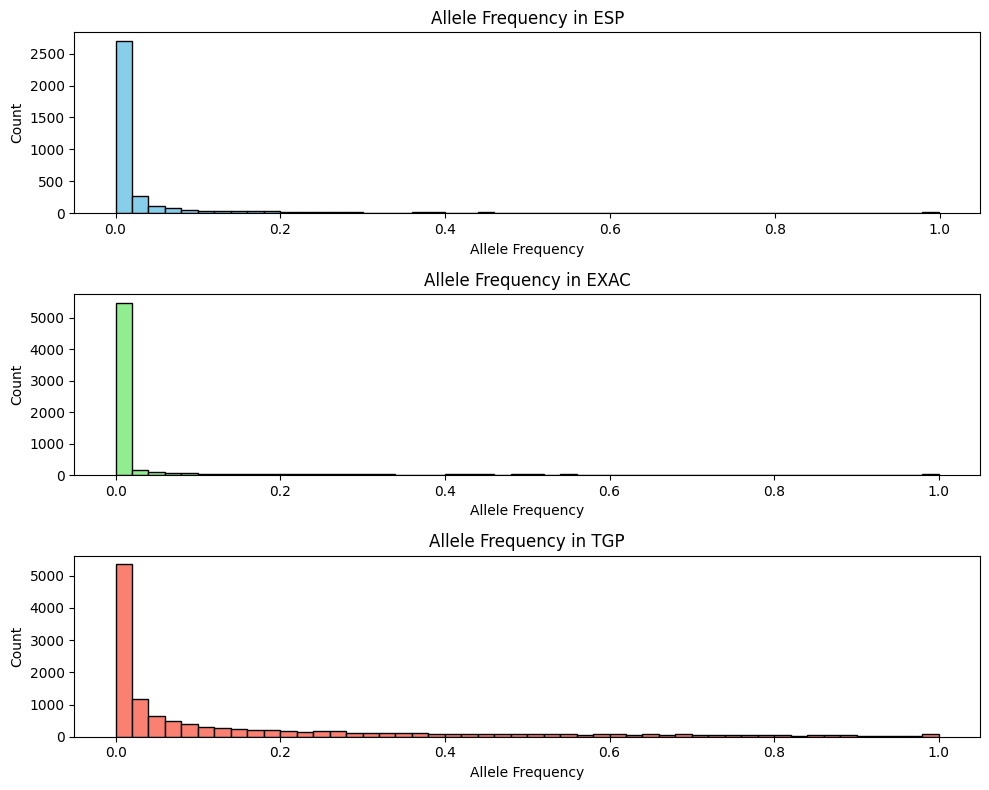

In [62]:
# histograms of allele frequencies
plt.figure(figsize=(10, 8))

bins = 50
datasets = [
    ('AF_ESP', 'skyblue', 'Allele Frequency in ESP'),
    ('AF_EXAC', 'lightgreen', 'Allele Frequency in EXAC'),
    ('AF_TGP', 'salmon', 'Allele Frequency in TGP')
]

for i, (col, color, title) in enumerate(datasets, 1):
    plt.subplot(3, 1, i)
    plt.hist(cv_df.filter(pl.col(col).is_not_null())[col].to_numpy(), 
             bins=bins, color=color, edgecolor='black')
    plt.title(title)
    plt.xlabel('Allele Frequency')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


# Clinical Significance by Variant Effect

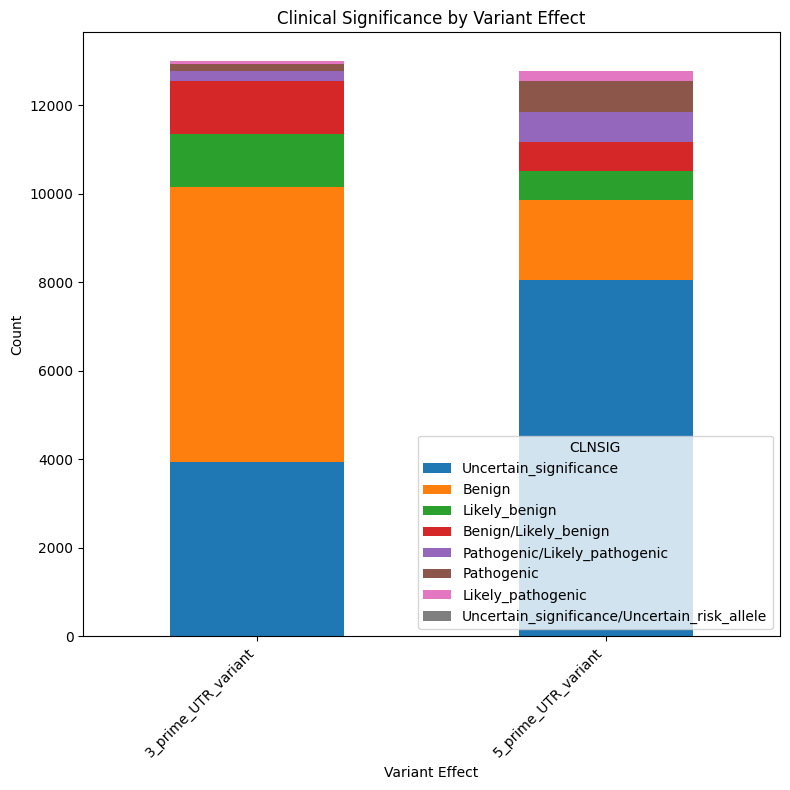

In [63]:
# group by Effect and CLNSIG, and count the occurrences
effect_clnsig_counts = cv_df.to_pandas().groupby(['MC_term', 'CLNSIG']).size().unstack().fillna(0)

top_8_clnsig = effect_clnsig_counts.sum(axis=0).nlargest(8).index

effect_clnsig_counts_top_8 = effect_clnsig_counts[top_8_clnsig]

# plot the stacked bar chart
effect_clnsig_counts_top_8.plot(kind='bar', stacked=True, figsize=(8, 8))
plt.title('Clinical Significance by Variant Effect')
plt.xlabel('Variant Effect')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Gene Distribution

In [ ]:
# count the number of variants associated with each gene
gene_counts = cv_df['GENEINFO'].to_pandas().value_counts()


print("Top 10 Genes with the Most Variants:")
print(gene_counts.head(10))

# plot the distribution of variants per gene 
plt.figure(figsize=(10, 6))
gene_counts.head(20).plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Top 20 Genes with the Most Variants')
plt.xlabel('Gene')
plt.ylabel('Number of Variants')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
